In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('main.ipynb'), '..')))

In [53]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.wcs import WCS
import pandas as pd
from scipy import interpolate
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input
from tensorflow.keras.optimizers import Adam

In [3]:
from utils.utilitas import inputx_outputy
from utils.arsitektur import StarNet
from utils.kma_method import KomodoMlipirAlgorithm
from utils.pre_processing import interpolate_nan, normalize_flux_median, standarize_output,decode_pred,mean_std
import seaborn as sns

In [4]:
#dapatkan data x dan y dimana x adalah flux dan y adalah vektor teff, logg, feh dan vin sin 1
"""
query
SELECT TOP 5000 *
FROM apogeeStar at INNER JOIN 
aspcapStar asr ON at.apogee_id = asr.apogee_id
where at.starflag = 0 
and at.vscatter < 1 and at.rv_logg != -9999 and at.SNR > 200 and asr.aspcapflag =0
and asr.vsini != -9999 and at.telescope = 'apo25m' and m_h != -9999

"""
name_file_1 = 'sdss_spectra_data_bintang_apogee.csv'
name_file_2 = 'file_id.csv'
folder_path = 'spectra_images_apogee'

x, y, wavelength = inputx_outputy(name_file_1, name_file_2, folder_path,untuk='train')
x_val, y_val, wavelength_val = inputx_outputy(name_file_1, name_file_2, folder_path, untuk='test')
#interpolasi nilai nan
for i in range(len(x)):
    x[i] = interpolate_nan(x[i])
    x[i] = normalize_flux_median(x[i],wavelength[i])

for i in range(len(x_val)):
    x_val[i] = interpolate_nan(x_val[i])
    x_val[i] = normalize_flux_median(x_val[i],wavelength_val[i])
    
mean_y,std_y = mean_std(y)   
y = standarize_output(y)

#split data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
#X_train_cnn, X_test_cnn,y_train_cnn,y_test_cnn = train_test_split(X_train,y_train, test_size=0.2,random_state=22)

In [5]:
# komodo n = 5
komodo_5 = [0.63479505, 0.09083289, 0.42500061, 0.25655968, 0.803561,   0.5574774,
 0.84808518, 0.85347074, 0.55757087, 0.44375022, 0.2768684,  0.07376918,
 0.49028438, 0.54182711, 0.63778676, 0.84474267]

#komodo n = 10
komodo_10 = [0.43803341, 0.79255546, 0.25906532, 0.42487103, 0.22479651, 0.66282992,
 0.07376419, 0.61606665, 0.37278885, 0.86455141, 0.33717008, 0.66282992,
 0.77520349, 0.53536994, 0.33717008, 0.16457245]

#komodo = 15
komodo_15 = [0.05668635, 0.48560174, 0.48922369, 0.46012899, 0.46196719, 0.68169073,
 0.24546223, 0.51542717, 0.45423118, 1.,         0.46380473, 0.29096663,
 0.4899689,  0.47045753, 0.47757844, 0.53420781]

In [71]:
starnet_5 = StarNet(X_train,y_train,X_test,y_test)
starnet_10 = StarNet(X_train,y_train,X_test,y_test)
starnet_15 = StarNet(X_train,y_train,X_test,y_test)
#decode
kom_5_parameter = starnet_5.decode(komodo_5)
kom_10_parameter = starnet_10.decode(komodo_10)
kom_15_parameter = starnet_15.decode(komodo_15)
 
print(f'Parameter Komodo n = 5 :{kom_5_parameter}')
print(f'Parameter Komodo n = 10 :{kom_10_parameter}')
print(f'Parameter Komodo n = 15 :{kom_15_parameter}')

Parameter Komodo n = 5 :[40, 16, 'tanh', 'tanh', 'glorot_normal', 'orthogonal', 7, 'elu', 'sigmoid', 'tanh', 'random_uniform', 'zeros', 'variance_scaling', 0.0001, 81, 32]
Parameter Komodo n = 10 :[32, 48, 'tanh', 'tanh', 'random_normal', 'lecun_normal', 2, 'sigmoid', 'tanh', 'elu', 'truncated_normal', 'lecun_normal', 'glorot_normal', 0.0001, 66, 1]
Parameter Komodo n = 15 :[16, 32, 'tanh', 'tanh', 'variance_scaling', 'lecun_uniform', 3, 'sigmoid', 'tanh', 'selu', 'variance_scaling', 'random_uniform', 'variance_scaling', 0.0001, 73, 8]


In [7]:
#train komodo_5
starnet_5.arsitektur_start_net(X_train, y_train, X_test, y_test, kom_5_parameter[0],kom_5_parameter[1],kom_5_parameter[2],kom_5_parameter[3],kom_5_parameter[4],kom_5_parameter[5],kom_5_parameter[6],kom_5_parameter[7],kom_5_parameter[8],kom_5_parameter[9],kom_5_parameter[10],kom_5_parameter[11],kom_5_parameter[12],kom_5_parameter[13],kom_5_parameter[14],kom_5_parameter[15])
hist_5 = starnet_5.history
model_5 = starnet_5.model

Epoch 1/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 254ms/step - loss: 1.0358 - val_loss: 0.9196
Epoch 2/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - loss: 1.0363 - val_loss: 0.9094
Epoch 3/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - loss: 1.0175 - val_loss: 0.9038
Epoch 4/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - loss: 1.0222 - val_loss: 0.9043
Epoch 5/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - loss: 1.0065 - val_loss: 0.8903
Epoch 6/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - loss: 0.9330 - val_loss: 0.8826
Epoch 7/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step - loss: 0.9381 - val_loss: 0.8753
Epoch 8/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 220ms/step - loss: 0.9849 - val_loss: 0.7693
Epoch 9/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - loss: 0.8472 - val_loss: 0.7384
Epoch 10/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step - loss: 0.7999 - val_loss: 0.6734
Epoch 11/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - loss: 0.7664 - val_loss: 0.6457
Epoch 12/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/ste

In [8]:
#train komodo_10
starnet_10.arsitektur_start_net(X_train, y_train, X_test, y_test, kom_10_parameter[0],kom_10_parameter[1],kom_10_parameter[2],kom_10_parameter[3],kom_10_parameter[4],kom_10_parameter[5],kom_10_parameter[6],kom_10_parameter[7],kom_10_parameter[8],kom_10_parameter[9],kom_10_parameter[10],kom_10_parameter[11],kom_10_parameter[12],kom_10_parameter[13],kom_10_parameter[14],kom_10_parameter[15])
hist_10 = starnet_10.history
model_10 = starnet_10.model

Epoch 1/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 118s 182ms/step - loss: 1.1758 - val_loss: 0.9692
Epoch 2/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 115s 181ms/step - loss: 1.0039 - val_loss: 0.9068
Epoch 3/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 115s 183ms/step - loss: 1.0045 - val_loss: 0.8987
Epoch 4/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 116s 183ms/step - loss: 1.0046 - val_loss: 0.9253
Epoch 5/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 118s 187ms/step - loss: 1.0839 - val_loss: 1.0100
Epoch 6/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 117s 185ms/step - loss: 1.1186 - val_loss: 0.9239
Epoch 7/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 116s 184ms/step - loss: 1.0657 - val_loss: 0.9744
Epoch 8/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 115s 182ms/step - loss: 1.0794 - val_loss: 0.9289
Epoch 9/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 109s 172ms/step - loss: 1.0542 - val_loss: 0.9017
Epoch 10/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 109s 173ms/step - loss: 1.0644 - val_loss: 0.9169
Epoch 11/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 109s 172ms/step - loss: 0.9973 - val_loss: 0.9144
Epoch 12

In [72]:
#train komodo_15
starnet_15.arsitektur_start_net(X_train, y_train, X_test, y_test, kom_15_parameter[0],kom_15_parameter[1],kom_15_parameter[2],kom_15_parameter[3],kom_15_parameter[4],kom_15_parameter[5],kom_15_parameter[6],kom_15_parameter[7],kom_15_parameter[8],None,kom_15_parameter[10],kom_15_parameter[11],kom_15_parameter[12],kom_15_parameter[13],kom_15_parameter[14],kom_15_parameter[15])
hist_15 = starnet_15.history
model_15 = starnet_15.model

Epoch 1/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - loss: 1.1877 - val_loss: 0.9279
Epoch 2/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - loss: 1.0356 - val_loss: 0.9321
Epoch 3/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 181ms/step - loss: 1.0398 - val_loss: 0.8705
Epoch 4/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 191ms/step - loss: 1.0288 - val_loss: 0.6873
Epoch 5/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 202ms/step - loss: 0.6520 - val_loss: 0.5794
Epoch 6/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 193ms/step - loss: 0.5311 - val_loss: 0.5685
Epoch 7/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 178ms/step - loss: 0.5328 - val_loss: 0.5015
Epoch 8/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 193ms/step - loss: 0.4899 - val_loss: 0.4456
Epoch 9/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 174ms/step - loss: 0.4663 - val_loss: 0.4009
Epoch 10/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 179ms/step - loss: 0.3680 - val_loss: 0.3635
Epoch 11/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 204ms/step - loss: 0.3794 - val_loss: 0.3809
Epoch 12/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 16

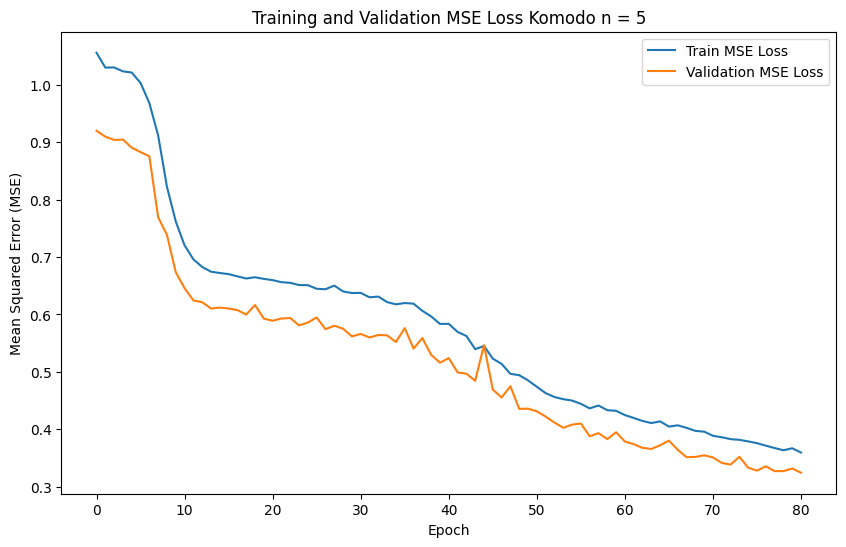

In [10]:
# plot train_valid komodo 5

plt.figure(figsize=(10, 6))
plt.plot(hist_5.history['loss'], label='Train MSE Loss')
plt.plot(hist_5.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 5')
plt.legend()
plt.show()

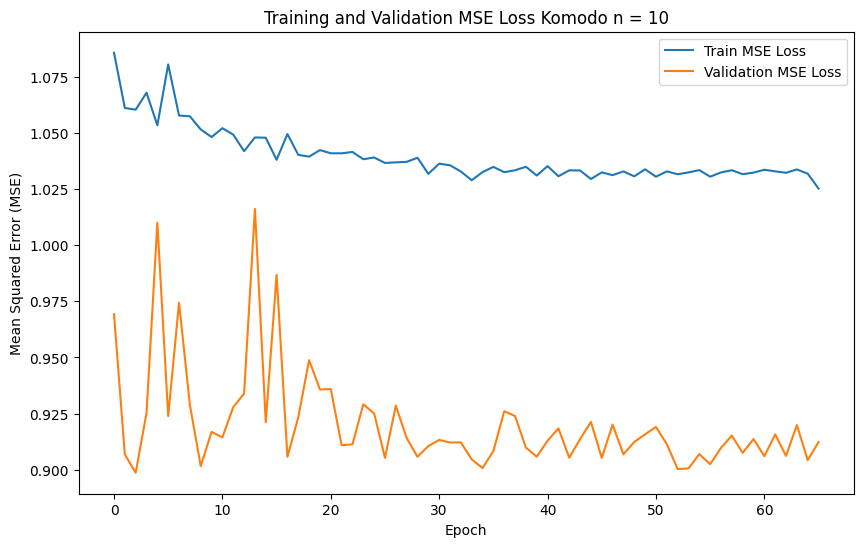

In [11]:
# plot train_valid komodo 10

plt.figure(figsize=(10, 6))
plt.plot(hist_10.history['loss'], label='Train MSE Loss')
plt.plot(hist_10.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 10')
plt.legend()
plt.show()

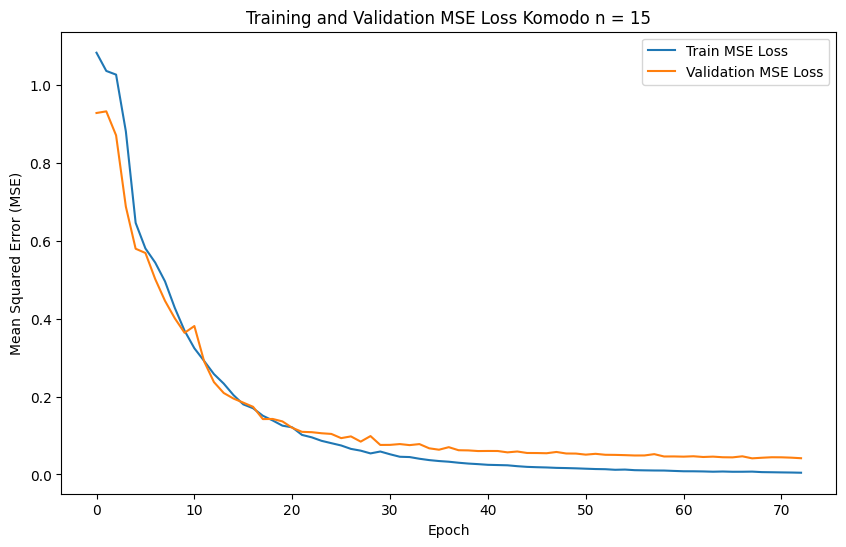

In [73]:
# plot train_valid komodo 15

plt.figure(figsize=(10, 6))
plt.plot(hist_15.history['loss'], label='Train MSE Loss')
plt.plot(hist_15.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 15')
plt.legend()
plt.show()

In [74]:
#hasil prediksi
y_pred_5 = model_5.predict(x_val)
y_pred_10 = model_10.predict(x_val)
y_pred_15 = model_15.predict(x_val)

y_pred_5 = decode_pred(y_pred_5,mean_y,std_y)
y_pred_10 = decode_pred(y_pred_10,mean_y,std_y)
y_pred_15 = decode_pred(y_pred_15,mean_y,std_y)

99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step


In [75]:
#nilai residual
residu_5 = y_pred_5 - y_val
residu_10 = y_pred_10 - y_val
residu_15 = y_pred_15 - y_val

In [76]:
#nilai mse dan rmse
mse_5 = np.mean(np.square(residu_5))
mse_10 = np.mean(np.square(residu_10))
mse_15 = np.mean(np.square(residu_15))

rmse_5 = np.sqrt(mse_5)
rmse_10 = np.sqrt(mse_10)
rmse_15 = np.sqrt(mse_15)

print(f'MSE Komodo n = 5 : {rmse_5}')
print(f'MSE Komodo n = 10 : {rmse_10}')
print(f'MSE Komodo n = 15 : {rmse_15}')

print(f'RMSE Komodo n = 5 : {rmse_5}')
print(f'RMSE Komodo n = 10 : {rmse_10}')
print(f'RMSE Komodo n = 15 : {rmse_15}')


MSE Komodo n = 5 : 103.84315570716767
MSE Komodo n = 10 : 169.67802915165373
MSE Komodo n = 15 : 30.961278214500226
RMSE Komodo n = 5 : 103.84315570716767
RMSE Komodo n = 10 : 169.67802915165373
RMSE Komodo n = 15 : 30.961278214500226


In [77]:
#plot residu SNR > 200

def plot_residu(residu,y_true,parameter):
    if parameter == 'teff':
        res = [teff[0] for teff in residu]
        y = [teff_true[0] for teff_true in y_true]
        kata = '$T_{eff}$'
        kata2 = '$\Delta T_{eff}$'
    elif parameter == 'log_g':
        res = [logg[1] for logg in residu]
        y = [logg_true[1] for logg_true in y_true]
        kata = '$log g$'
        kata2 = '$\Delta log g$'
    elif parameter == 'vsini':
        res = [vsini[2] for vsini in residu]
        y = [vsini_true[2] for vsini_true in y_true]
        kata = '$v sin i$'
        kata2 = '$\Delta v sin i$' 
    else:
        res = [metal[3] for metal in residu]
        y = [metal_true[3] for metal_true in y_true]
        kata = '$M/H$'
        kata2 = '$\Delta M/H$'
    
    res = np.array(res)
    y = np.array(y)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [3, 1]})


    ax[0].scatter(y, res, color='blue', s=10, alpha=0.7)
    ax[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    ax[0].set_xlabel(f'ASPCAP DR17 {kata}')
    ax[0].set_ylabel(f'{kata2} (StarNet - DR17)')

    # Hitung rata-rata dan standar deviasi residual
    mean_residual = np.mean(res)
    std_residual = np.std(res)
    
    # Hitung posisi tengah pada sumbu x dan y
    x_center = (y.min() + y.max()) / 2  # Posisi tengah sumbu x
    y_center = 0  # Agar teks berada dekat dengan garis nol pada sumbu y
    
    # Tambahkan teks di tengah
    ax[0].text(x_center, y_center, f"$\\bar{{m}}$={mean_residual:.2f}, $s$={std_residual:.2f}",
               fontsize=10, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    # Histogram distribusi residual di kanan
    sns.histplot(res, bins=30, kde=True, ax=ax[1], color='blue', orientation='horizontal')
    ax[1].set_ylabel('')
    ax[1].set_xlabel('Density')
    ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
C:\Users\itdev.support22\AppData\Local\Temp\ipykernel_12560\3810704085.py:8: SyntaxWarning: invalid escape sequence '\D'
  kata2 = '$\Delta T_{eff}$'
C:\Users\itdev.support22\AppData\Local\Temp\ipykernel_12560\3810704085.py:13: SyntaxWarning: invalid escape sequence '\D'
  kata2 = '$\Delta log g$'
C:\Users\itdev.support22\AppData\Local\Temp\ipykernel_12560\3810704085.py:18: SyntaxWarning: invalid escape sequence '\D'
  kata2 = '$\Delta v sin i$'
C:\Users\itdev.support22\AppData\Local\Temp\ipykernel_12560\3810704085.py:23: SyntaxWarning: invalid escape sequence '\D'
  kata2 = '$\Delta M/H

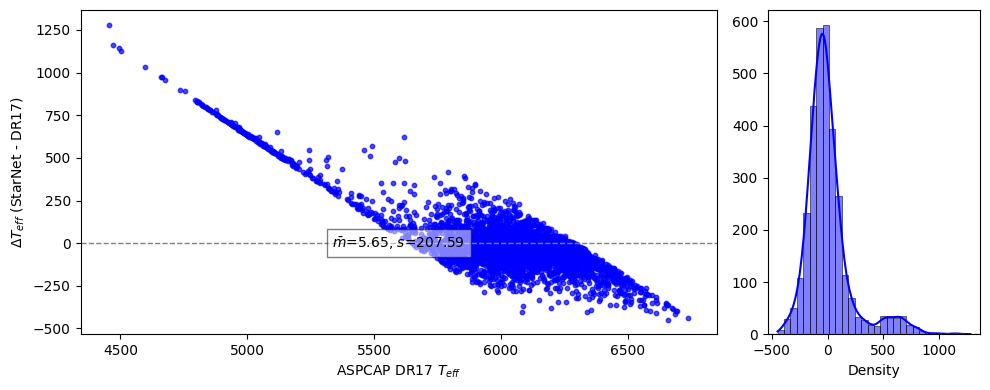

In [17]:
#plot residu teff 5

plot_residu(residu_5,y_val,'teff')


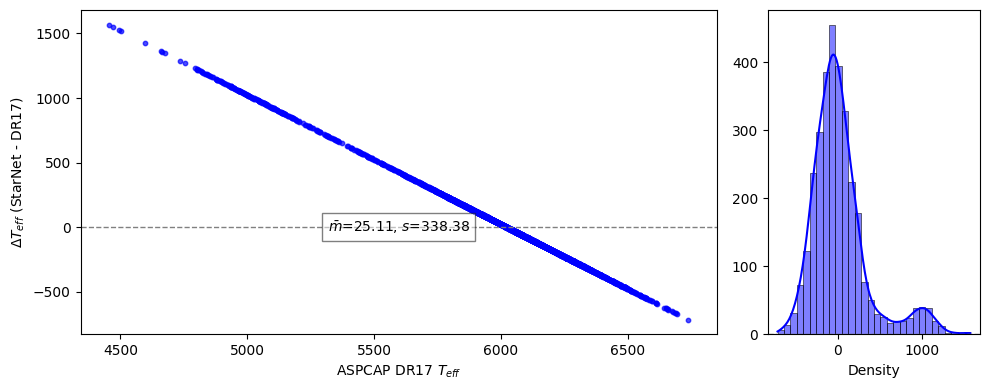

In [18]:
#plot residu teff 10

plot_residu(residu_10,y_val,'teff')

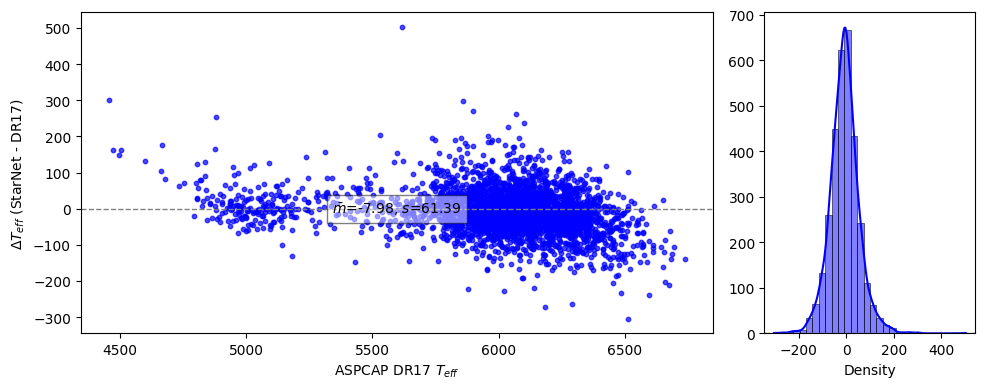

In [78]:
#plot residu teff 15

plot_residu(residu_15,y_val,'teff')

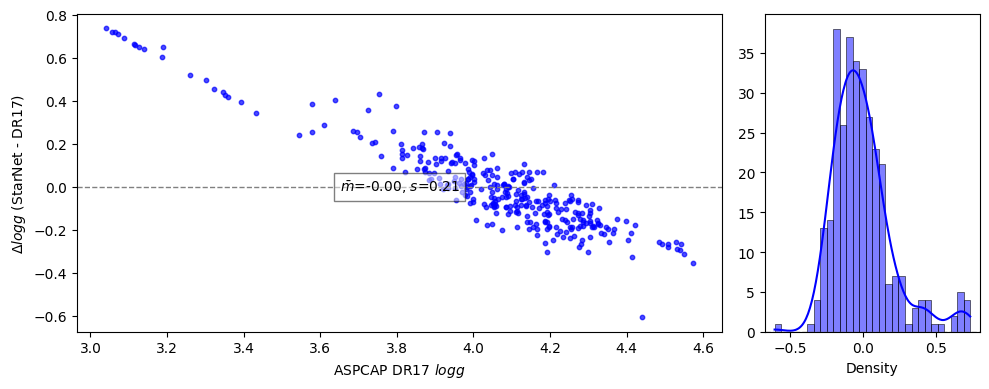

In [20]:
#plot residu logg 5
sub = 10
plot_residu(residu_5[::sub],y_val[::sub],'log_g')

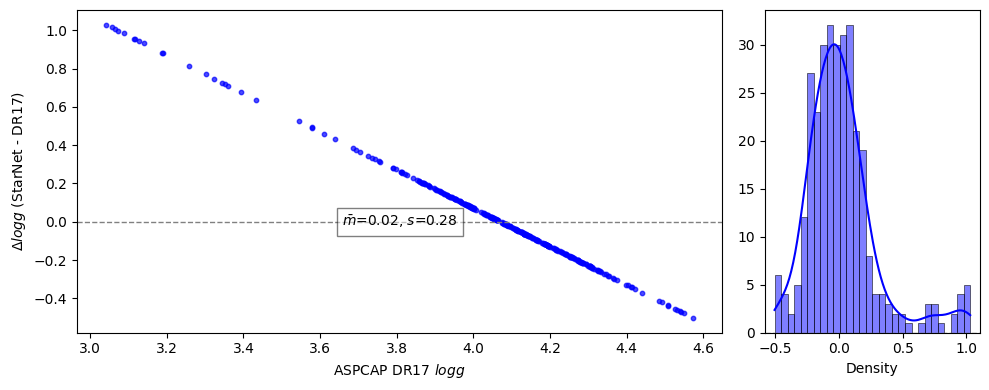

In [21]:
#plot residu logg 10
plot_residu(residu_10[::sub],y_val[::sub],'log_g')

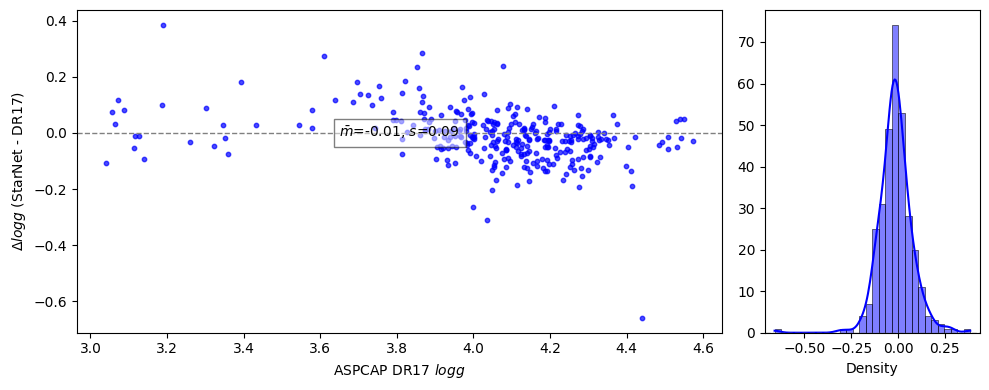

In [79]:
#plot residu logg 15
plot_residu(residu_15[::sub],y_val[::sub],'log_g')

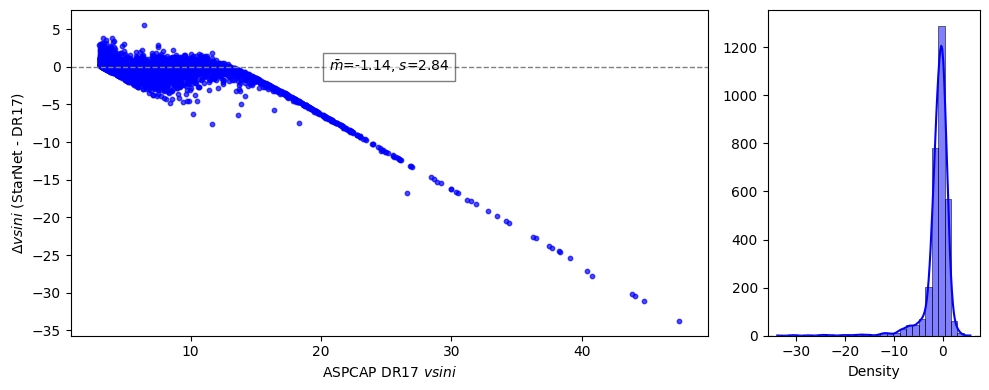

In [80]:
#plot residu vsini 5
plot_residu(residu_5,y_val,'vsini')

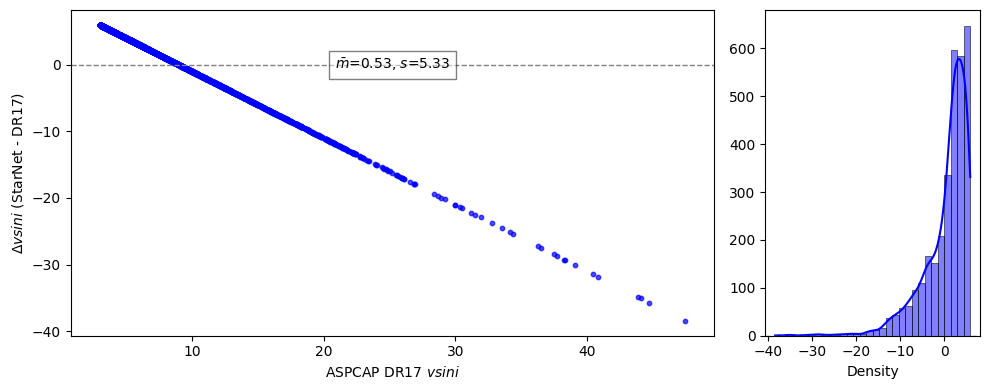

In [24]:
#plot residu vsini 10
plot_residu(residu_10,y_val,'vsini')

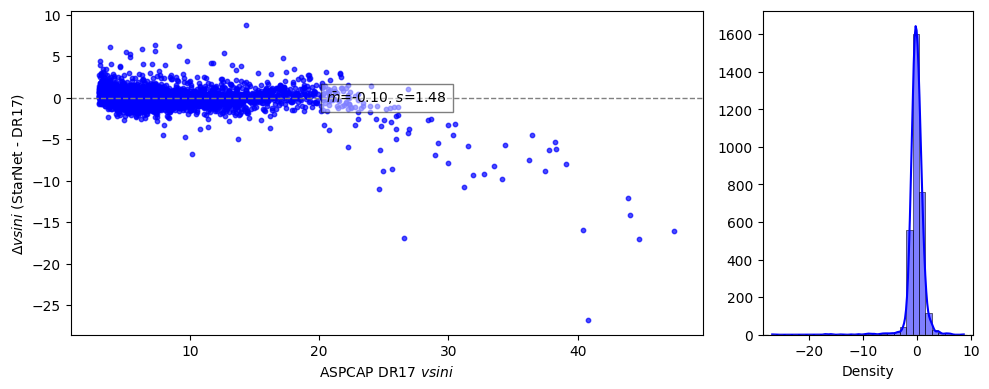

In [81]:
#plot residu vsini 15
plot_residu(residu_15,y_val,'vsini')

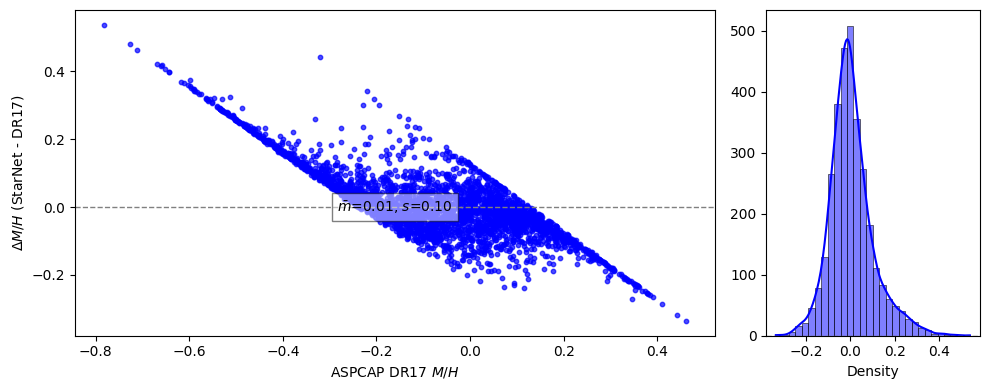

In [26]:
#plot residu  metalisitas 5
plot_residu(residu_5,y_val,'metal')

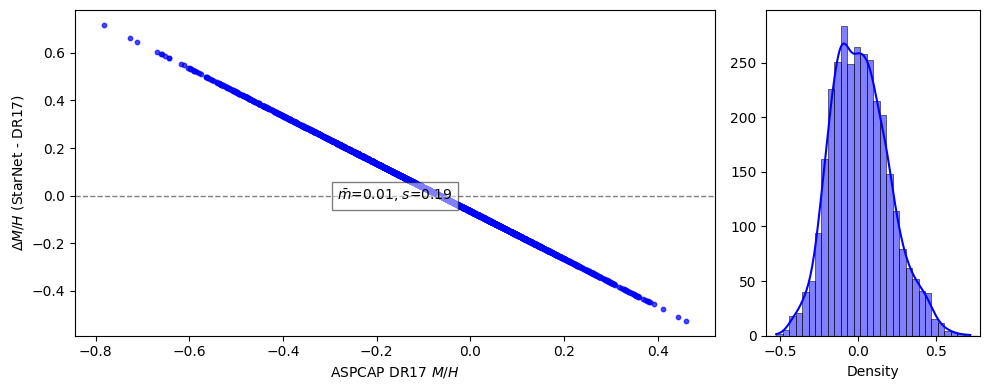

In [27]:
#plot residu  metalisitas 10
plot_residu(residu_10,y_val,'metal')

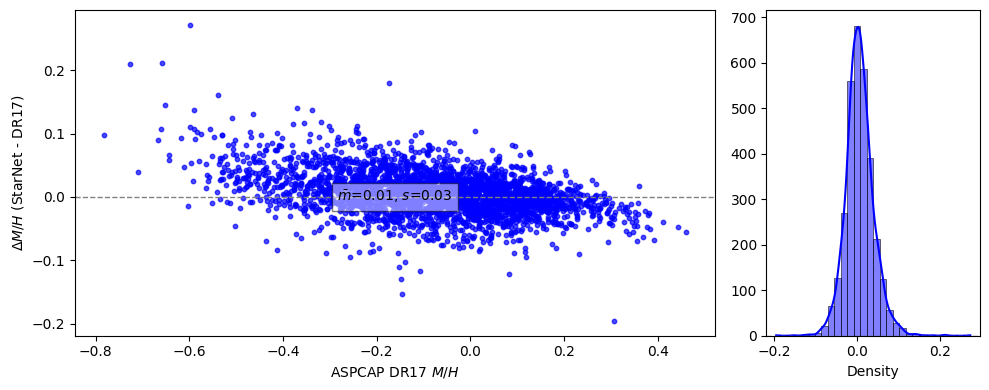

In [82]:
#plot residu  metalisitas 15
plot_residu(residu_15,y_val,'metal')

SNR < 200

In [29]:
#dapatkan data x dan y dimana x adalah flux dan y adalah vektor teff, logg, feh dan vin sin 1
"""
query
SELECT TOP 5000 *
FROM apogeeStar at INNER JOIN 
aspcapStar asr ON at.apogee_id = asr.apogee_id
where at.starflag = 0 
and at.vscatter < 1 and at.rv_logg != -9999 and at.SNR <= 200 and asr.aspcapflag =0
and asr.vsini != -9999 and at.telescope = 'apo25m' and m_h != -9999

"""
name_file_1 = 'sdss_spectra_data_bintang_apogee_low_SNR.csv'
name_file_2 = 'file_id_low_snr.csv'
folder_path = 'spectra_images_apogee_low_SNR'

x_low, y_low, wavelength_low = inputx_outputy(name_file_1, name_file_2, folder_path,untuk='train')
x_val_low, y_val_low, wavelength_val_low = inputx_outputy(name_file_1, name_file_2, folder_path, untuk='test')
#interpolasi nilai nan
for i in range(len(x_low)):
    x_low[i] = interpolate_nan(x_low[i])
    x_low[i] = normalize_flux_median(x_low[i],wavelength_low[i])

for i in range(len(x_val_low)):
    x_val_low[i] = interpolate_nan(x_val_low[i])
    x_val_low[i] = normalize_flux_median(x_val_low[i],wavelength_val_low[i])
    
mean_y_low,std_y_low = mean_std(y_low)   
y_low = standarize_output(y_low)

#split data menjadi data latih dan data uji
X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(x_low, y_low, test_size=0.2, random_state=42)
#X_train_cnn, X_test_cnn,y_train_cnn,y_test_cnn = train_test_split(X_train,y_train, test_size=0.2,random_state=22)

In [30]:
starnet_5_low = StarNet(X_train_low,y_train_low,X_test_low,y_test_low)
starnet_10_low = StarNet(X_train_low,y_train_low,X_test_low,y_test_low)
starnet_15_low = StarNet(X_train_low,y_train_low,X_test_low,y_test_low)

In [31]:
#train komodo_5
starnet_5_low.arsitektur_start_net(X_train_low, y_train_low, X_test_low, y_test_low, kom_5_parameter[0],kom_5_parameter[1],kom_5_parameter[2],kom_5_parameter[3],kom_5_parameter[4],kom_5_parameter[5],kom_5_parameter[6],kom_5_parameter[7],kom_5_parameter[8],kom_5_parameter[9],kom_5_parameter[10],kom_5_parameter[11],kom_5_parameter[12],kom_5_parameter[13],kom_5_parameter[14],kom_5_parameter[15])
hist_5_low = starnet_5_low.history
model_5_low = starnet_5_low.model

Epoch 1/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 215ms/step - loss: 1.2962 - val_loss: 0.8175
Epoch 2/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - loss: 1.0221 - val_loss: 0.8115
Epoch 3/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - loss: 1.0962 - val_loss: 0.7992
Epoch 4/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - loss: 1.0221 - val_loss: 0.8035
Epoch 5/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - loss: 1.0567 - val_loss: 0.8004
Epoch 6/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - loss: 1.1042 - val_loss: 0.7998
Epoch 7/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - loss: 0.9583 - val_loss: 0.7968
Epoch 8/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - loss: 1.0471 - val_loss: 0.8012
Epoch 9/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - loss: 1.0000 - val_loss: 0.7890
Epoch 10/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - loss: 1.0768 - val_loss: 0.7884
Epoch 11/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - loss: 0.9524 - val_loss: 0.7783
Epoch 12/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step

In [32]:
#train komodo_10
starnet_10_low.arsitektur_start_net(X_train_low, y_train_low, X_test_low, y_test_low, kom_10_parameter[0],kom_10_parameter[1],kom_10_parameter[2],kom_10_parameter[3],kom_10_parameter[4],kom_10_parameter[5],kom_10_parameter[6],kom_10_parameter[7],kom_10_parameter[8],kom_10_parameter[9],kom_10_parameter[10],kom_10_parameter[11],kom_10_parameter[12],kom_10_parameter[13],kom_10_parameter[14],kom_10_parameter[15])
hist_10_low = starnet_10_low.history
model_10_low = starnet_10_low.model

Epoch 1/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 106s 179ms/step - loss: 1.2503 - val_loss: 0.8460
Epoch 2/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 105s 183ms/step - loss: 1.1244 - val_loss: 0.8080
Epoch 3/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 99s 173ms/step - loss: 1.0478 - val_loss: 0.8360
Epoch 4/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 105s 183ms/step - loss: 1.1471 - val_loss: 0.8136
Epoch 5/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 99s 173ms/step - loss: 1.0740 - val_loss: 0.7751
Epoch 6/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 99s 173ms/step - loss: 0.8863 - val_loss: 0.6079
Epoch 7/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 99s 173ms/step - loss: 0.6823 - val_loss: 0.3736
Epoch 8/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 99s 173ms/step - loss: 0.3891 - val_loss: 0.3044
Epoch 9/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 100s 175ms/step - loss: 0.3210 - val_loss: 0.2763
Epoch 10/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 99s 173ms/step - loss: 0.2526 - val_loss: 0.2561
Epoch 11/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 99s 173ms/step - loss: 0.2892 - val_loss: 0.2516
Epoch 12/66
572

In [83]:
#train komodo_15
starnet_15_low.arsitektur_start_net(X_train_low, y_train_low, X_test_low, y_test_low, kom_15_parameter[0],kom_15_parameter[1],kom_15_parameter[2],kom_15_parameter[3],kom_15_parameter[4],kom_15_parameter[5],kom_15_parameter[6],kom_15_parameter[7],kom_15_parameter[8],None,kom_15_parameter[10],kom_15_parameter[11],kom_15_parameter[12],kom_15_parameter[13],kom_15_parameter[14],kom_15_parameter[15])
hist_15_low = starnet_15_low.history
model_15_low = starnet_15_low.model

Epoch 1/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 171ms/step - loss: 1.1289 - val_loss: 0.8121
Epoch 2/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 174ms/step - loss: 1.0553 - val_loss: 0.8088
Epoch 3/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 201ms/step - loss: 1.0240 - val_loss: 0.8231
Epoch 4/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 201ms/step - loss: 0.9738 - val_loss: 0.6987
Epoch 5/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 201ms/step - loss: 0.8697 - val_loss: 0.4969
Epoch 6/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 162ms/step - loss: 0.6609 - val_loss: 0.4388
Epoch 7/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 181ms/step - loss: 0.6669 - val_loss: 0.3943
Epoch 8/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - loss: 0.5374 - val_loss: 0.3610
Epoch 9/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 203ms/step - loss: 0.5291 - val_loss: 0.3257
Epoch 10/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 187ms/step - loss: 0.4630 - val_loss: 0.2718
Epoch 11/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 190ms/step - loss: 0.2973 - val_loss: 0.2237
Epoch 12/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 15

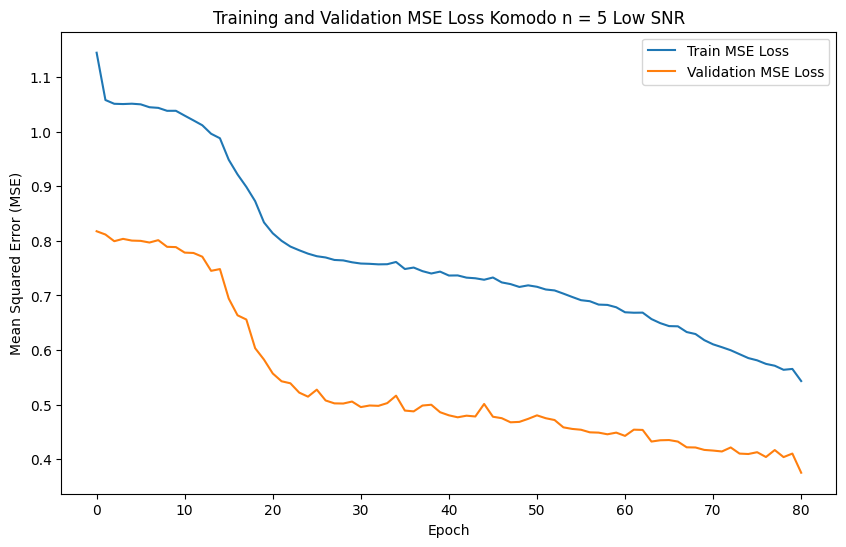

In [34]:
# plot train_valid komodo 5

plt.figure(figsize=(10, 6))
plt.plot(hist_5_low.history['loss'], label='Train MSE Loss')
plt.plot(hist_5_low.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 5 Low SNR')
plt.legend()
plt.show()

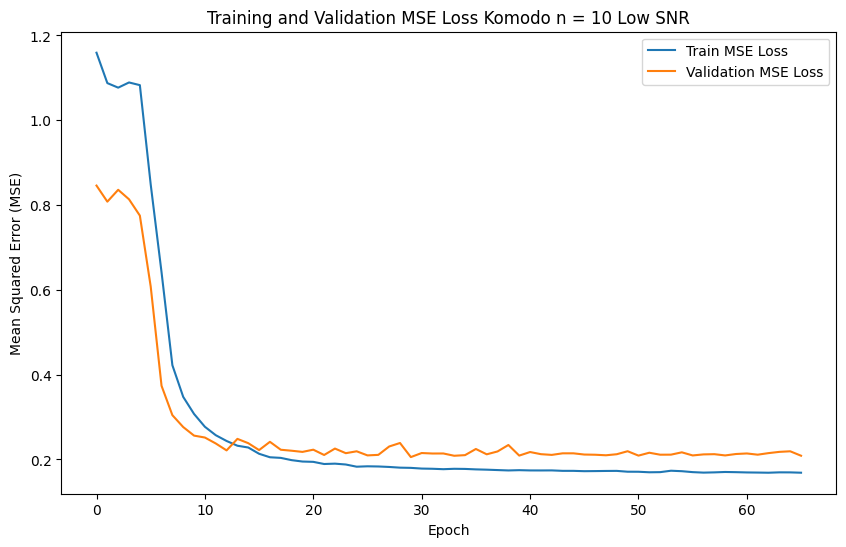

In [35]:
# plot train_valid komodo 10

plt.figure(figsize=(10, 6))
plt.plot(hist_10_low.history['loss'], label='Train MSE Loss')
plt.plot(hist_10_low.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 10 Low SNR')
plt.legend()
plt.show()

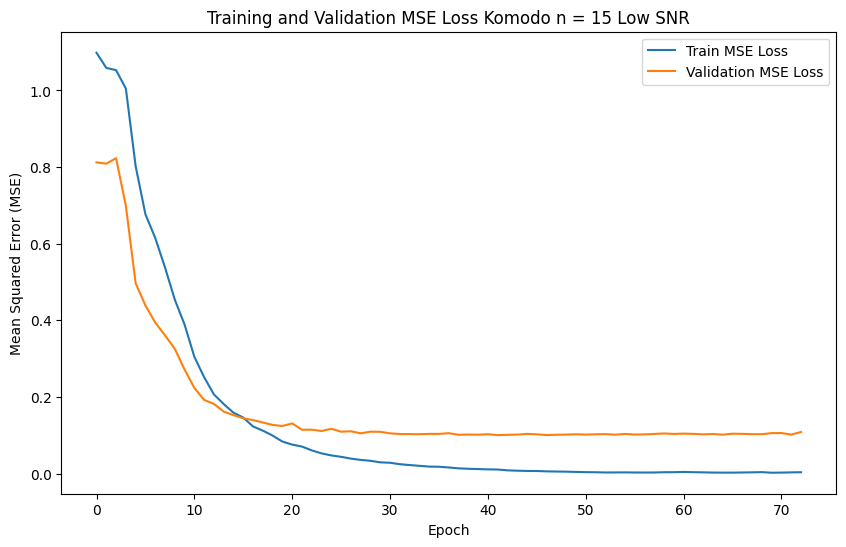

In [84]:
# plot train_valid komodo 15

plt.figure(figsize=(10, 6))
plt.plot(hist_15_low.history['loss'], label='Train MSE Loss')
plt.plot(hist_15_low.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 15 Low SNR')
plt.legend()
plt.show()

In [85]:
y_pred_5_low = model_5_low.predict(x_val_low)
y_pred_10_low = model_10_low.predict(x_val_low)
y_pred_15_low = model_15_low.predict(x_val_low)

y_pred_5_low = decode_pred(y_pred_5_low,mean_y_low,std_y_low)
y_pred_10_low = decode_pred(y_pred_10_low,mean_y_low,std_y_low)
y_pred_15_low = decode_pred(y_pred_15_low,mean_y_low,std_y_low)

90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step


In [38]:
y_pred_5 = model_5.predict(x_val)
y_pred_10 = model_10.predict(x_val)
y_pred_15 = model_15.predict(x_val)

y_pred_5 = decode_pred(y_pred_5,mean_y,std_y)
y_pred_10 = decode_pred(y_pred_10,mean_y,std_y)
y_pred_15 = decode_pred(y_pred_15,mean_y,std_y)

99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step


In [86]:
#nilai residual
residu_5_low = y_pred_5_low - y_val_low
residu_10_low = y_pred_10_low - y_val_low
residu_15_low = y_pred_15_low - y_val_low

#nilai mse dan rmse
mse_5_low = np.mean(np.square(residu_5_low))
mse_10_low = np.mean(np.square(residu_10_low))
mse_15_low = np.mean(np.square(residu_15_low))

rmse_5_low = np.sqrt(mse_5_low)
rmse_10_low = np.sqrt(mse_10_low)
rmse_15_low = np.sqrt(mse_15_low)

print(f'MSE Komodo n = 5 : {rmse_5_low}')
print(f'MSE Komodo n = 10 : {rmse_10_low}')
print(f'MSE Komodo n = 15 : {rmse_15_low}')

print(f'RMSE Komodo n = 5 : {rmse_5_low}')
print(f'RMSE Komodo n = 10 : {rmse_10_low}')
print(f'RMSE Komodo n = 15 : {rmse_15_low}')


MSE Komodo n = 5 : 107.1752096563893
MSE Komodo n = 10 : 87.69067298006382
MSE Komodo n = 15 : 48.25075691631208
RMSE Komodo n = 5 : 107.1752096563893
RMSE Komodo n = 10 : 87.69067298006382
RMSE Komodo n = 15 : 48.25075691631208


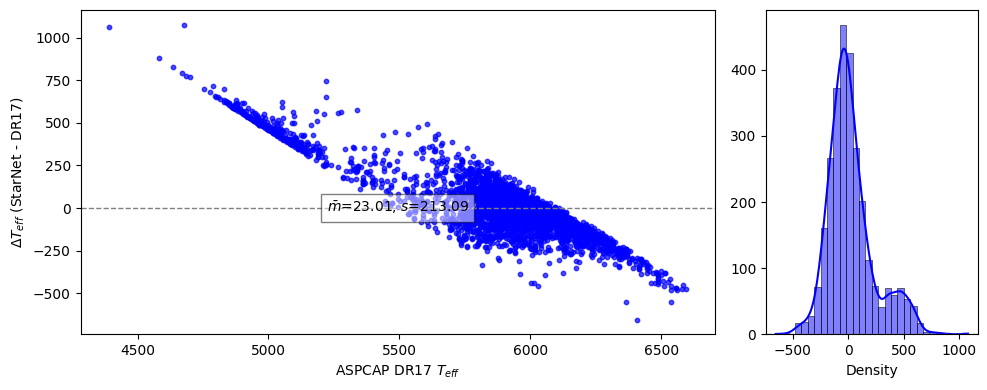

In [40]:
#plot residu teff 5

plot_residu(residu_5_low,y_val_low,'teff')

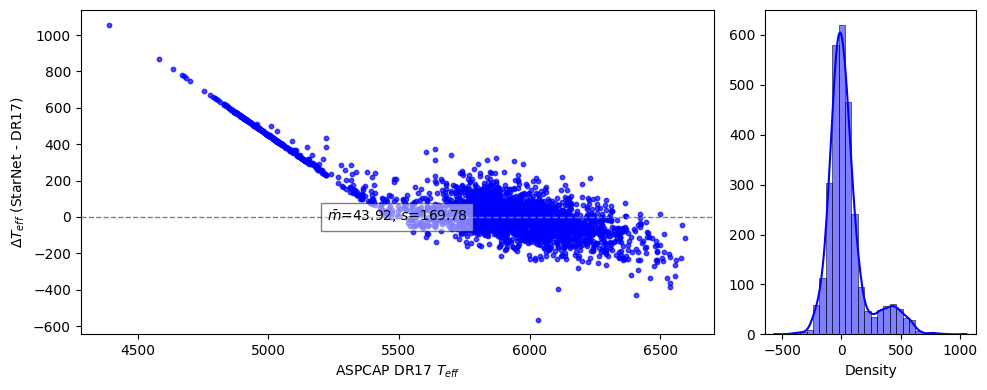

In [41]:
#plot residu teff 10

plot_residu(residu_10_low,y_val_low,'teff')

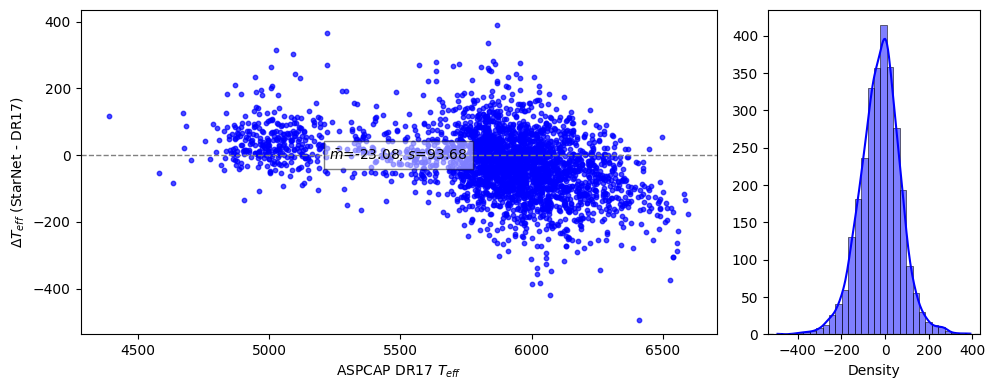

In [87]:
#plot residu teff 15

plot_residu(residu_15_low,y_val_low,'teff')

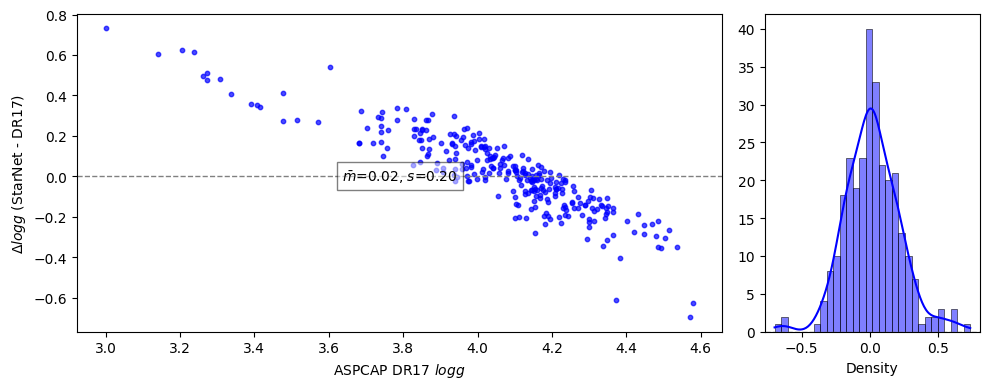

In [43]:
#plot residu logg 5
sub = 10
plot_residu(residu_5_low[::sub],y_val_low[::sub],'log_g')

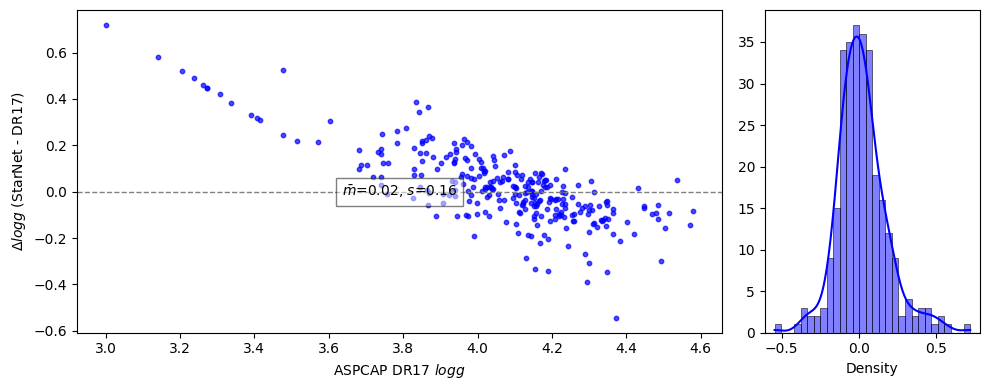

In [44]:
#plot residu logg 10
plot_residu(residu_10_low[::sub],y_val_low[::sub],'log_g')

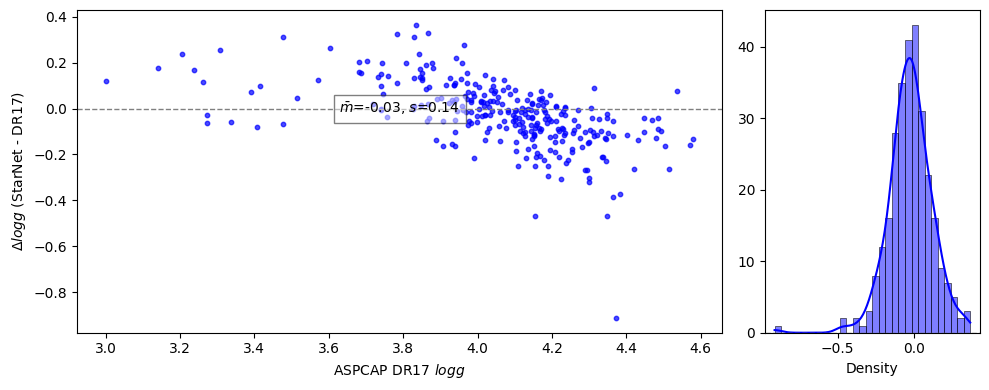

In [88]:
#plot residu logg 15
plot_residu(residu_15_low[::sub],y_val_low[::sub],'log_g')

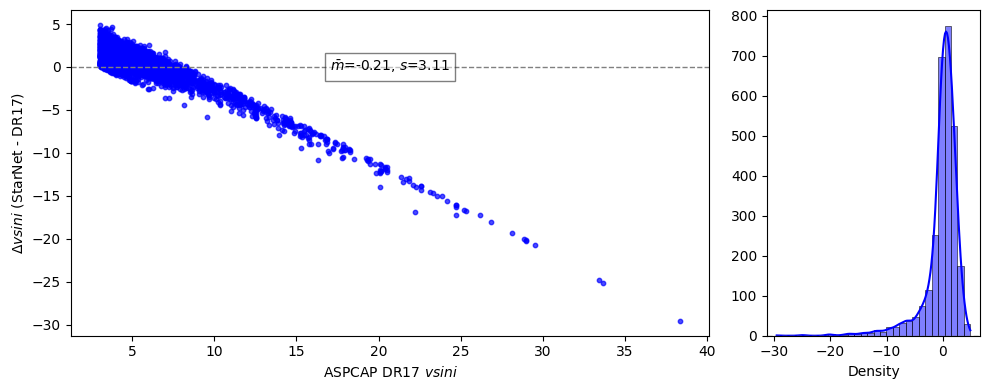

In [46]:
#plot residu vsini 5
plot_residu(residu_5_low,y_val_low,'vsini')

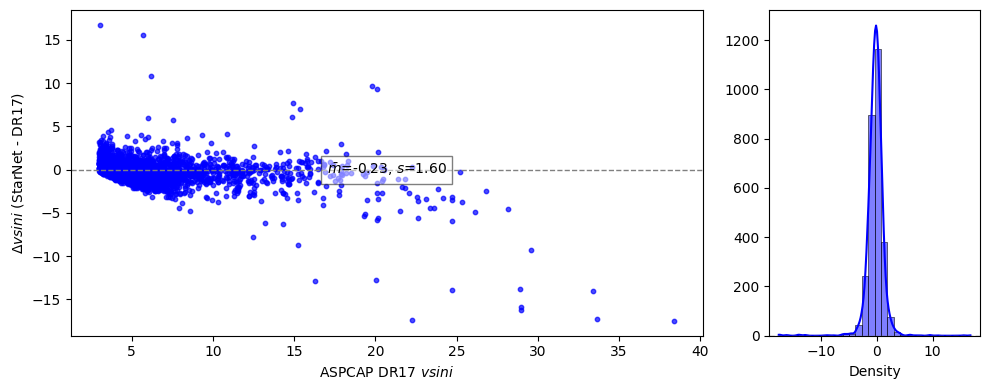

In [47]:
#plot residu vsini 10
plot_residu(residu_10_low,y_val_low,'vsini')

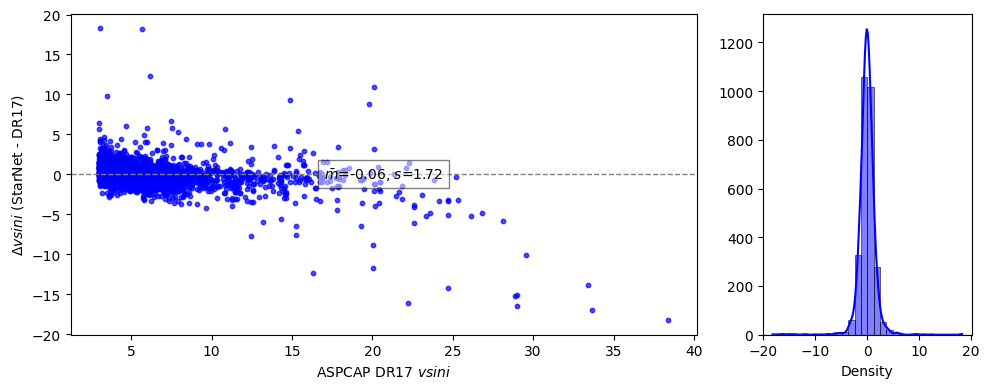

In [89]:
#plot residu vsini 15
plot_residu(residu_15_low,y_val_low,'vsini')

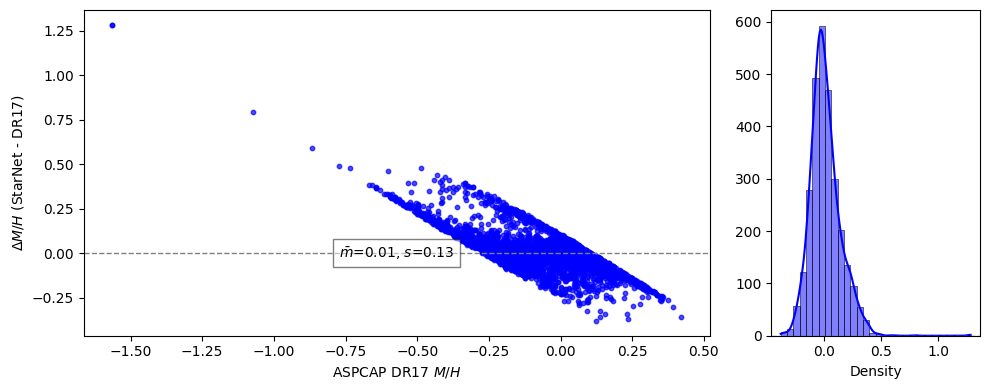

In [49]:
#plot residu  metalisitas 5
plot_residu(residu_5_low,y_val_low,'metal')

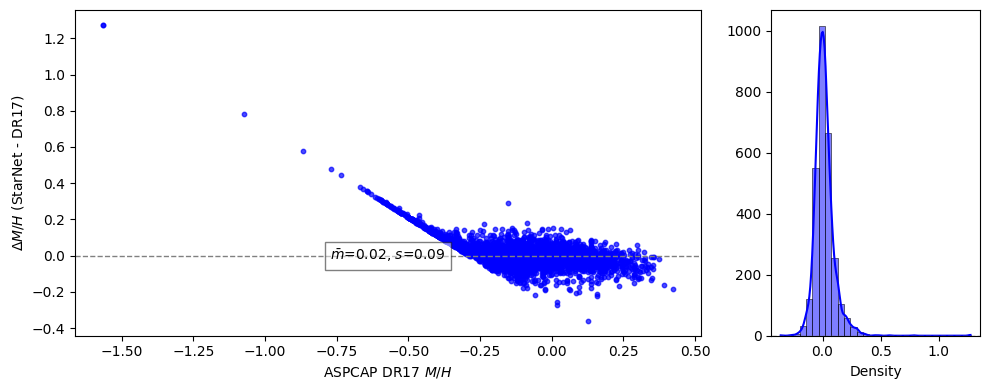

In [50]:
#plot residu  metalisitas 10
plot_residu(residu_10_low,y_val_low,'metal')

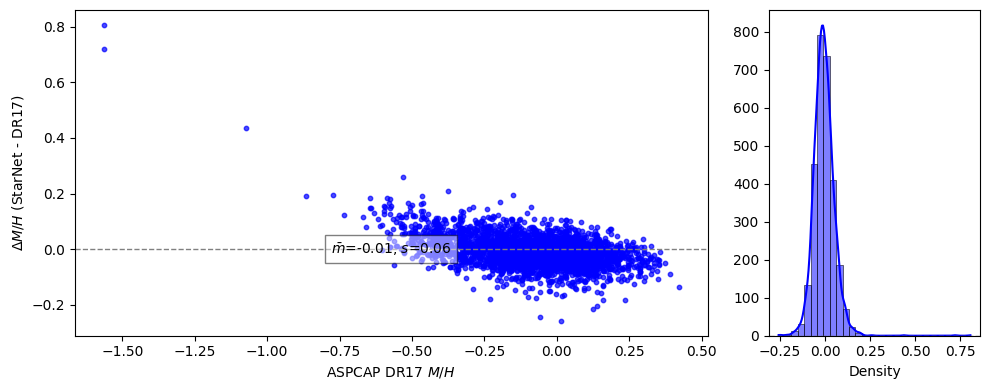

In [90]:
#plot residu  metalisitas 15
plot_residu(residu_15_low,y_val_low,'metal')

In [56]:
#Starnet default 

models = Sequential()
        
models.add(Input(shape=(8575, 1)))

# Conv Layer 1
models.add(Conv1D(filters=4,kernel_size=16, activation='relu', kernel_initializer='he_normal'))

# Conv Layer 2
models.add(Conv1D(filters=16,kernel_size=32, activation='relu', kernel_initializer='he_normal'))

# Max Pooling
models.add(MaxPooling1D(pool_size=(4,)))

# Flattening
models.add(Flatten())

# Fully Connected Layer 1
models.add(Dense(256, activation='relu', kernel_initializer='he_normal'))

# Fully Connected Layer 2
models.add(Dense(128, activation='relu', kernel_initializer='he_normal'))

# Output layer untuk empat parameter bintang
models.add(Dense(4))

# Kompilasi model
models.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

In [57]:
hist_ori = models.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=1)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 389ms/step - loss: 40.0184 - val_loss: 1.0172
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 305ms/step - loss: 1.1045 - val_loss: 0.8633
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 307ms/step - loss: 0.9043 - val_loss: 0.8468
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 327ms/step - loss: 0.8784 - val_loss: 0.6386
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 391ms/step - loss: 0.6345 - val_loss: 0.6051
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 362ms/step - loss: 0.5962 - val_loss: 0.5086
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 378ms/step - loss: 0.5468 - val_loss: 0.5118
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 319ms/step - loss: 0.4863 - val_loss: 0.4568
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 325ms/step - loss: 0.4715 - val_loss: 0.5415
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 350ms/step - loss: 0.4830 - val_loss: 0.5751
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 303ms/step - loss: 0.4807 - val_loss: 0.3814
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━

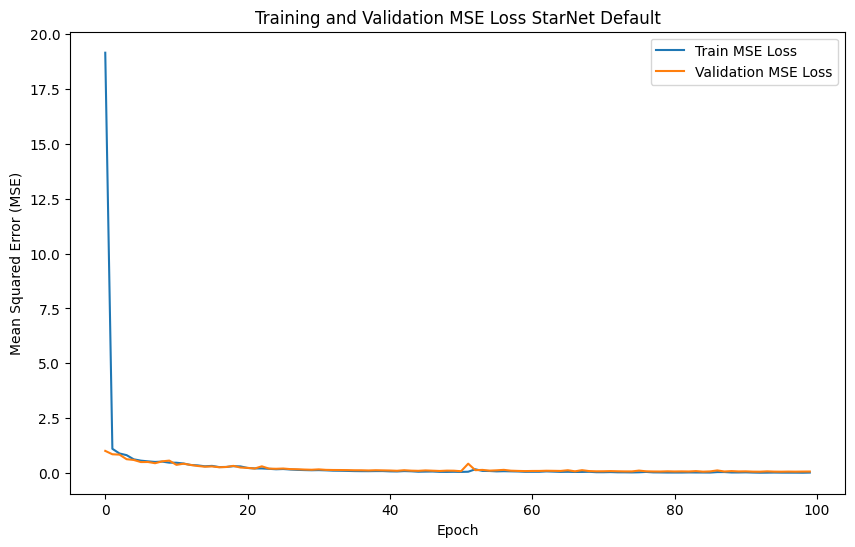

In [58]:
# plot train_valid komodo 

plt.figure(figsize=(10, 6))
plt.plot(hist_ori.history['loss'], label='Train MSE Loss')
plt.plot(hist_ori.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss StarNet Default')
plt.legend()
plt.show()

In [65]:
y_predict_ori = models.predict(x_val)
y_predict_ori = decode_pred(y_predict_ori,mean_y,std_y)
residu_ori = y_predict_ori - y_val

99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step


In [66]:
#nilai mse dan rmse
mse_ori = np.mean(np.square(residu_ori))
rmse_ori = np.sqrt(mse_ori)

print(f'MSE Komodo ori : {mse_ori}')

print(f'RMSE Komodo ori : {rmse_ori}')



MSE Komodo ori : 1877.114474320395
RMSE Komodo ori : 43.3256791559047


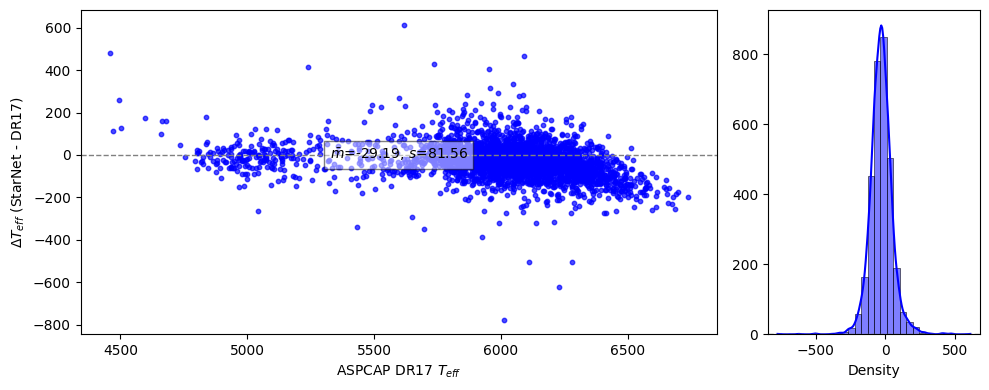

In [67]:
#plot residu teff 

plot_residu(residu_ori,y_val,'teff')

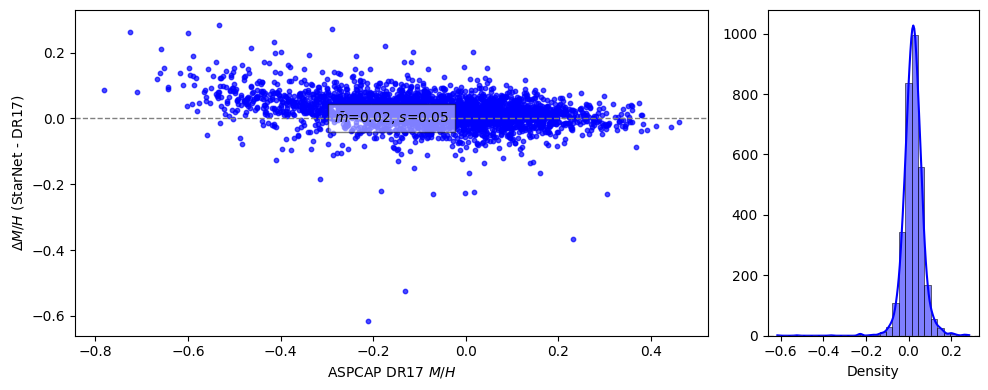

In [68]:
#plot residu  metalisitas 
plot_residu(residu_ori,y_val,'metal')

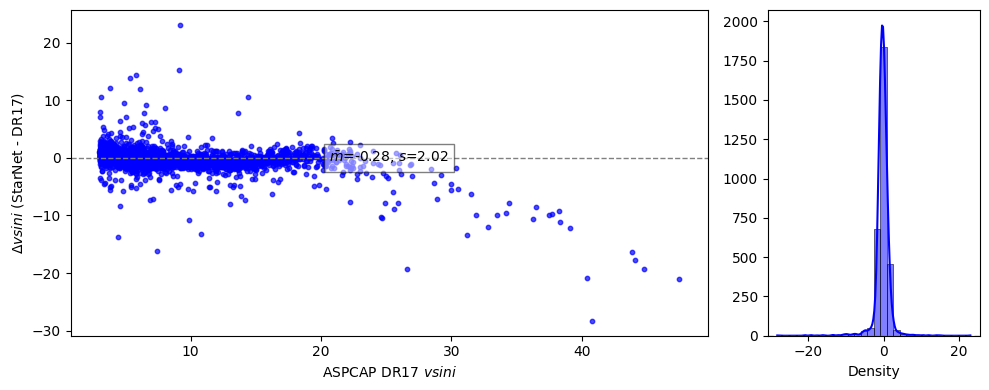

In [69]:
#plot residu vsini 
plot_residu(residu_ori,y_val,'vsini')

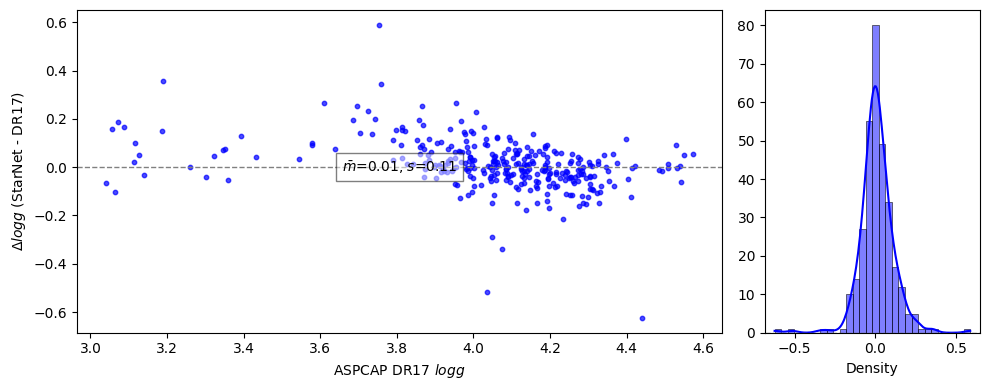

In [70]:
#plot residu logg 
sub_ori = 10
plot_residu(residu_ori[::sub_ori],y_val[::sub_ori],'log_g')